Running Gillespie simulation of Oosawa model
  kn=1e-04,  ka=1e-02,  nc=2,  m0=200
  Simulation ended at t = 41.95
  Final state:  m=0,  P=16,  M=200
  Total events: 184


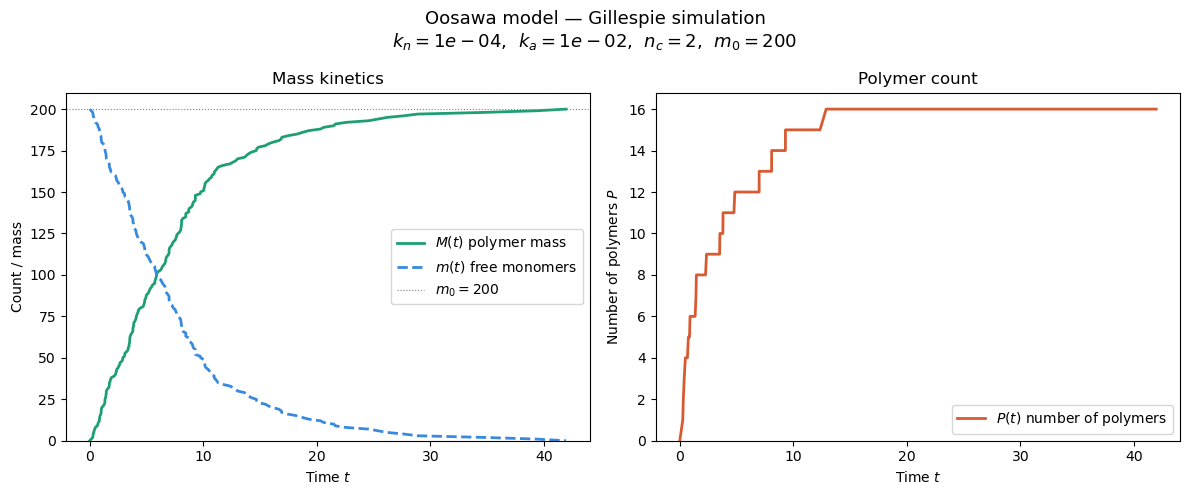

In [7]:
"""
Oosawa Model - Gillespie Stochastic Simulation
================================================
Week 1, Question 1: Write code implementing Oosawa model using Gillespie approach.

Model reactions:
  Nucleation:   nc monomers → polymer of size nc,   rate = kn * m(t)^nc
  Association:  polymer(j) + monomer → polymer(j+1), rate = ka * m(t) per polymer
"""

import numpy as np
import matplotlib.pyplot as plt


def gillespie_oosawa(kn, ka, nc, m0, max_events=100_000):
    """
    Gillespie simulation of the Oosawa model (Nucleation + Association).

    Parameters
    ----------
    kn         : float  - nucleation rate constant
    ka         : float  - association rate constant
    nc         : int    - critical nucleus size
    m0         : int    - initial number of free monomers
    max_events : int    - maximum number of reaction events

    Returns
    -------
    t_series : array - time points
    m_series : array - free monomer count
    P_series : array - number of polymers
    M_series : array - total polymer mass
    """

    # --- Initial conditions ---
    t = 0.0
    m = m0
    P = 0
    M = 0

    t_series = [t]
    m_series = [m]
    P_series = [P]
    M_series = [M]

    rng = np.random.default_rng()

    for _ in range(max_events):

        # Step 1: Calculate reaction rates
        r_nucl  = kn * (m ** nc) if m >= nc        else 0.0
        r_assoc = ka * m * P     if m > 0 and P > 0 else 0.0
        r_total = r_nucl + r_assoc

        if r_total <= 0:
            break

        # Step 2: Time to next event (exponential distribution)
        tau = -np.log(rng.random()) / r_total
        t  += tau

        # Step 3: Which reaction fires?
        u = rng.random()
        if u < r_nucl / r_total:
            # Nucleation: consume nc monomers, create one new polymer
            m -= nc
            M += nc
            P += 1
        else:
            # Association: consume 1 monomer, add to existing polymer
            m -= 1
            M += 1

        # Step 4: Record state
        t_series.append(t)
        m_series.append(m)
        P_series.append(P)
        M_series.append(M)

        if m <= 0:
            break

    return (np.array(t_series), np.array(m_series),
            np.array(P_series),  np.array(M_series))


# --- Parameters ---
KN = 1e-4
KA = 1e-2
NC = 2
M0 = 200

print(f"Running Gillespie simulation of Oosawa model")
print(f"  kn={KN:.0e},  ka={KA:.0e},  nc={NC},  m0={M0}")

t, m, P, M = gillespie_oosawa(kn=KN, ka=KA, nc=NC, m0=M0)

print(f"  Simulation ended at t = {t[-1]:.2f}")
print(f"  Final state:  m={m[-1]},  P={P[-1]},  M={M[-1]}")
print(f"  Total events: {len(t)-1}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    f"Oosawa model — Gillespie simulation\n"
    f"$k_n={KN:.0e}$,  $k_a={KA:.0e}$,  $n_c={NC}$,  $m_0={M0}$",
    fontsize=13
)

ax = axes[0]
ax.plot(t, M, color="#1D9E75", lw=2, label="$M(t)$ polymer mass")
ax.plot(t, m, color="#378ADD", lw=2, ls="--", label="$m(t)$ free monomers")
ax.axhline(M0, color="gray", lw=0.8, ls=":", label=f"$m_0={M0}$")
ax.set_xlabel("Time $t$"); ax.set_ylabel("Count / mass")
ax.set_title("Mass kinetics"); ax.legend(fontsize=10); ax.set_ylim(bottom=0)

ax = axes[1]
ax.plot(t, P, color="#D85A30", lw=2, label="$P(t)$ number of polymers")
ax.set_xlabel("Time $t$"); ax.set_ylabel("Number of polymers $P$")
ax.set_title("Polymer count"); ax.legend(fontsize=10); ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()